Downloading...
From: https://drive.google.com/uc?id=1f0wQLwjRL43pJf0ay0ElfJqc1ijFr5sn
To: /content/retail_sales_mock_data.csv
100%|██████████| 1.09k/1.09k [00:00<00:00, 2.22MB/s]


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB
None

Пропуски по столбцам:
 SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64

Описательная статистика для SalesAmount:
 count       48.000000
mean     11768.541667
std       2257.544863
min       7783.000000
25%      10219.750000
50%      11851.000000
75%      13014.000000
max      17996.000000
Name: SalesAmount, dtype: float64


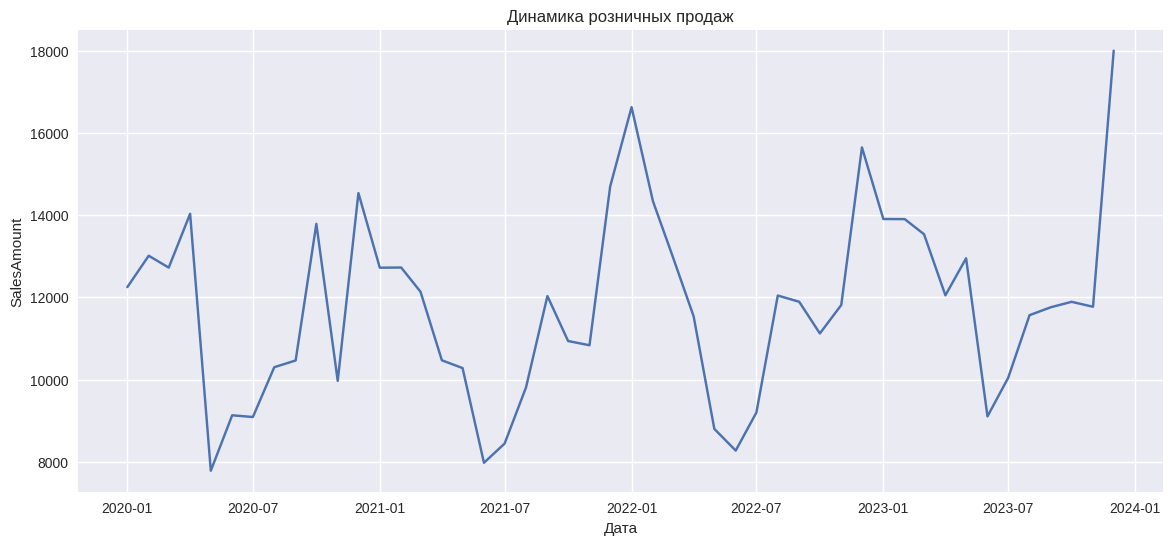

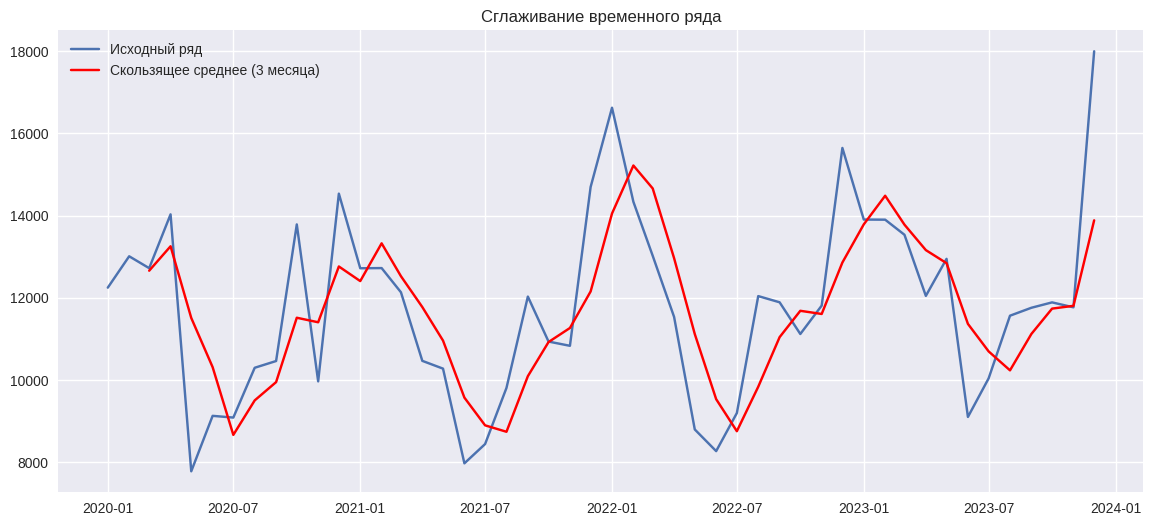

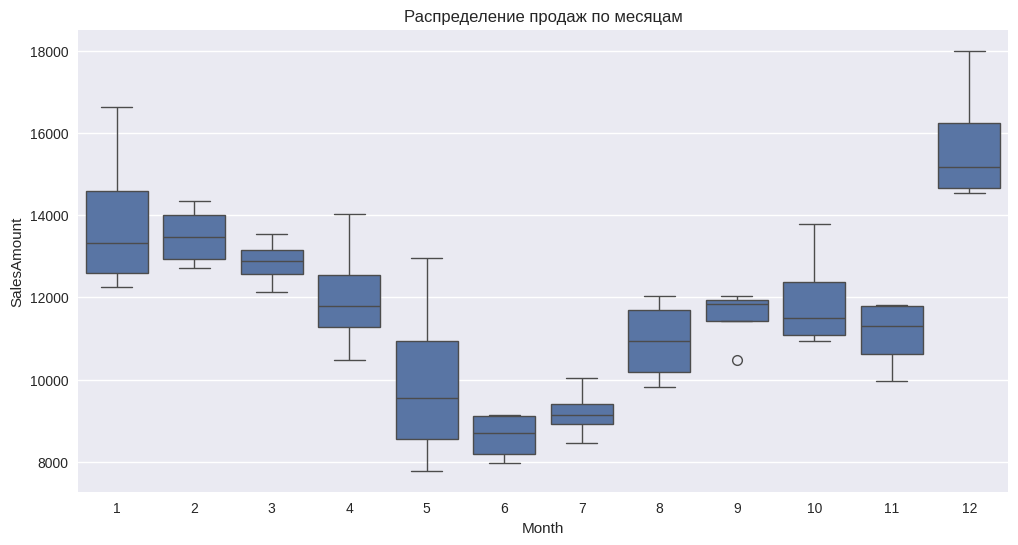

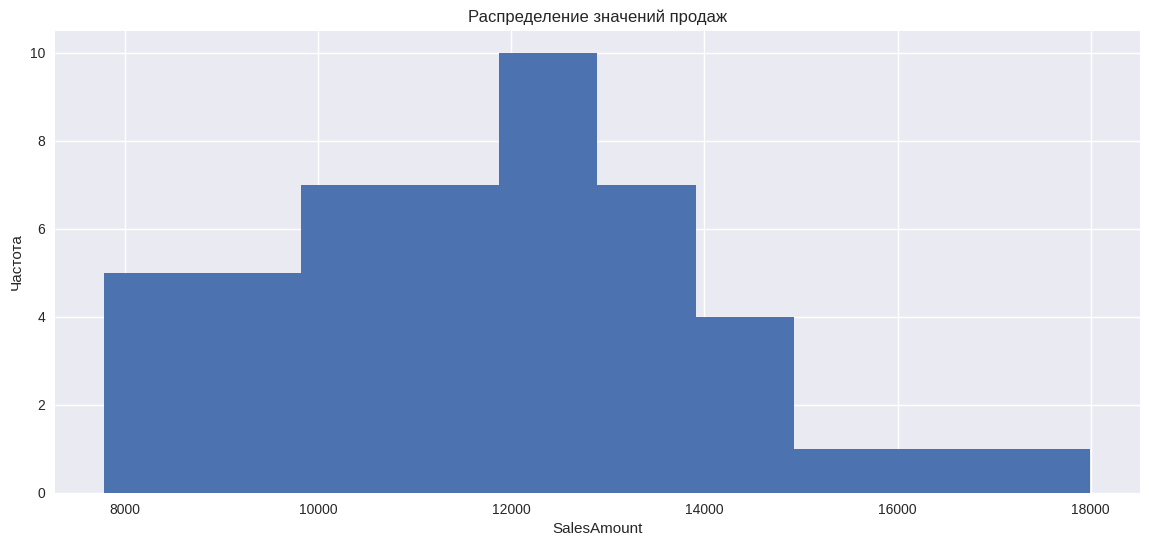

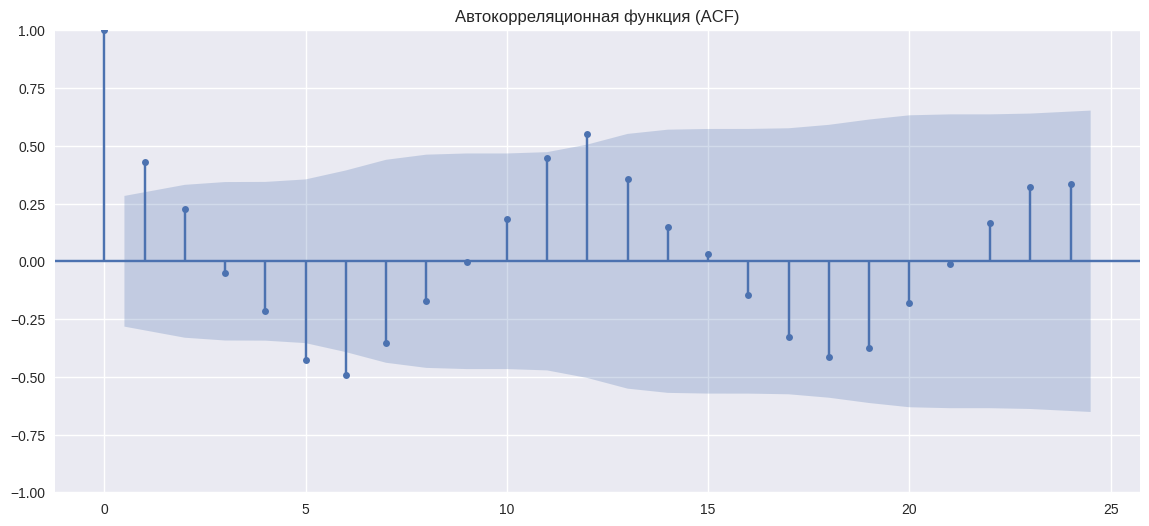

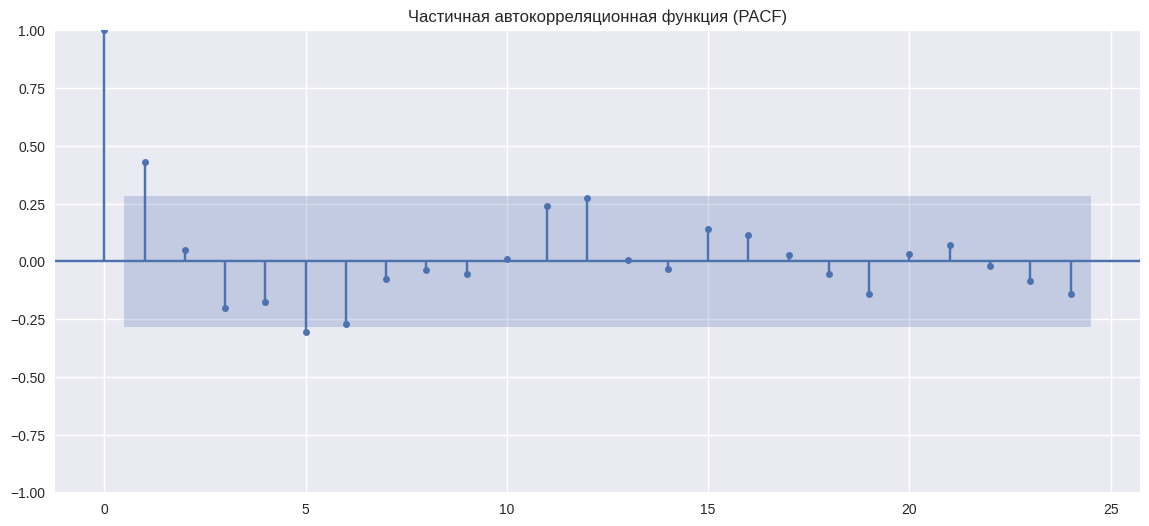

In [11]:
# ============================================
# 2.1 Разведочный анализ данных (EDA)
# Провести предварительный анализ временного ряда, визуализации различных типов
# ============================================

# Импорт библиотек для анализа данных и визуализации
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 6)

# ==============================
# Установка gdown для загрузки файла по ссылке
# ==============================
!pip install --quiet gdown
import gdown

# ==============================
# Ссылка на файл в Google Drive
# ==============================
file_id = "1f0wQLwjRL43pJf0ay0ElfJqc1ijFr5sn"
url = f"https://drive.google.com/uc?id={file_id}"
output = "retail_sales_mock_data.csv"

# Загрузка файла
gdown.download(url, output, quiet=False)

# ==============================
# Загрузка CSV в DataFrame
# ==============================
df = pd.read_csv(output)

# Просмотр первых строк
df.head()

# ==============================
# Преобразование столбца Date в datetime
# ==============================
df['Date'] = pd.to_datetime(df['Date'])

# Установка даты как временного индекса
df.set_index('Date', inplace=True)

# Сортировка по времени
df.sort_index(inplace=True)

# Выделение целевой переменной
ts = df['SalesAmount']

# Проверка структуры данных
print(df.info())

# Проверка на пропуски
print("\nПропуски по столбцам:\n", df.isnull().sum())

# Базовая статистика
print("\nОписательная статистика для SalesAmount:\n", ts.describe())

# ==============================
# Визуализация временного ряда
# ==============================
plt.plot(ts)
plt.title("Динамика розничных продаж")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")
plt.show()

# ==============================
# Скользящее среднее (сглаживание)
# ==============================
rolling_mean = ts.rolling(window=3).mean()

plt.plot(ts, label="Исходный ряд")
plt.plot(rolling_mean, label="Скользящее среднее (3 месяца)", color="red")
plt.legend()
plt.title("Сглаживание временного ряда")
plt.show()

# ==============================
# Boxplot по месяцам (проверка сезонности)
# ==============================
df['Month'] = df.index.month

plt.figure(figsize=(12,6))
sns.boxplot(x='Month', y='SalesAmount', data=df)
plt.title("Распределение продаж по месяцам")
plt.show()

# ==============================
# Гистограмма распределения
# ==============================
plt.hist(ts, bins=10)
plt.title("Распределение значений продаж")
plt.xlabel("SalesAmount")
plt.ylabel("Частота")
plt.show()

# ==============================
# Автокорреляция и частичная автокорреляция
# ==============================
plot_acf(ts, lags=24)
plt.title("Автокорреляционная функция (ACF)")
plt.show()

plot_pacf(ts, lags=24)
plt.title("Частичная автокорреляционная функция (PACF)")
plt.show()

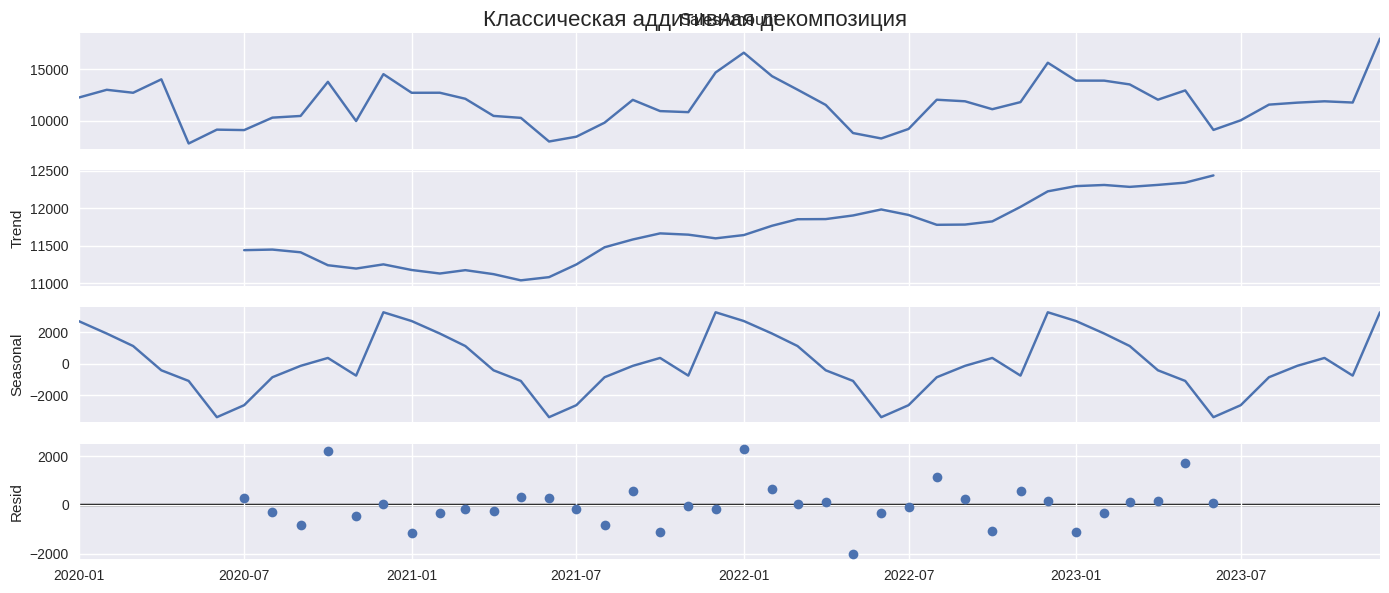

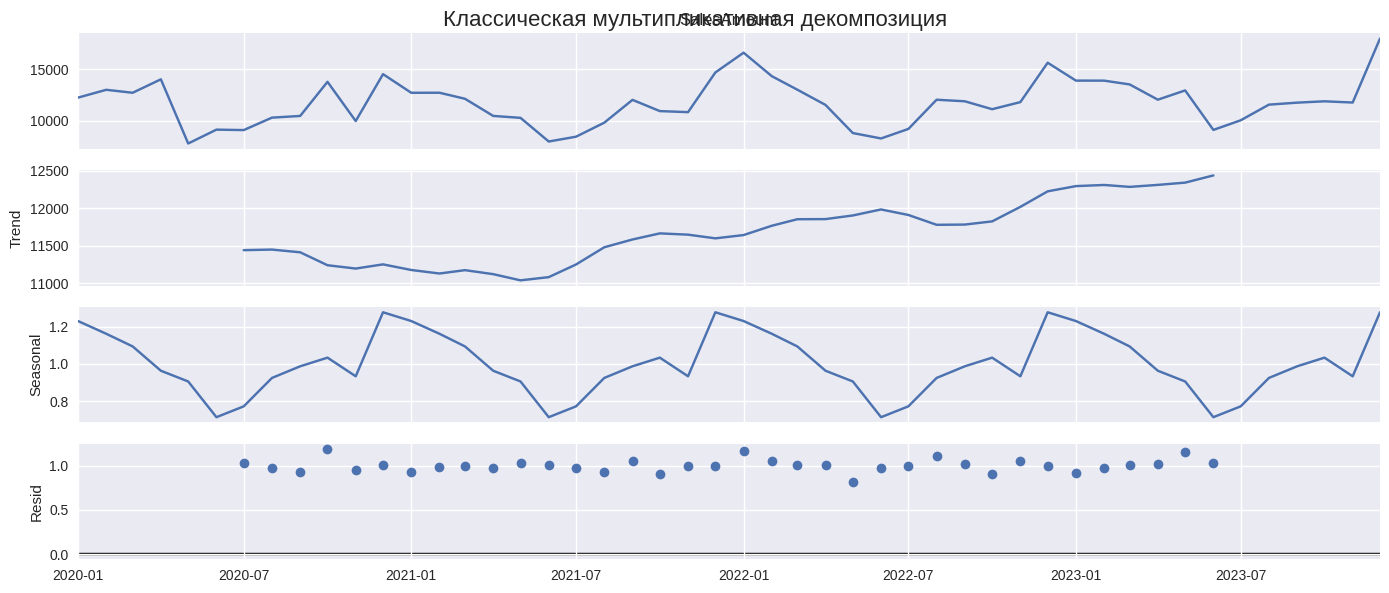

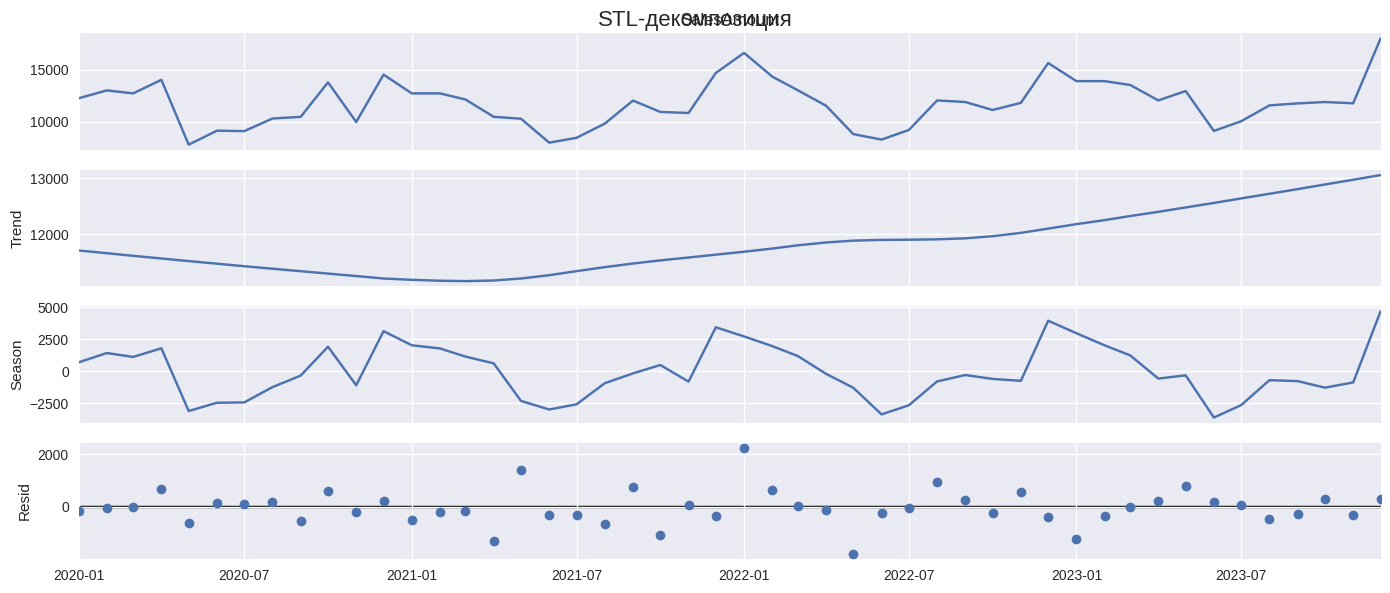

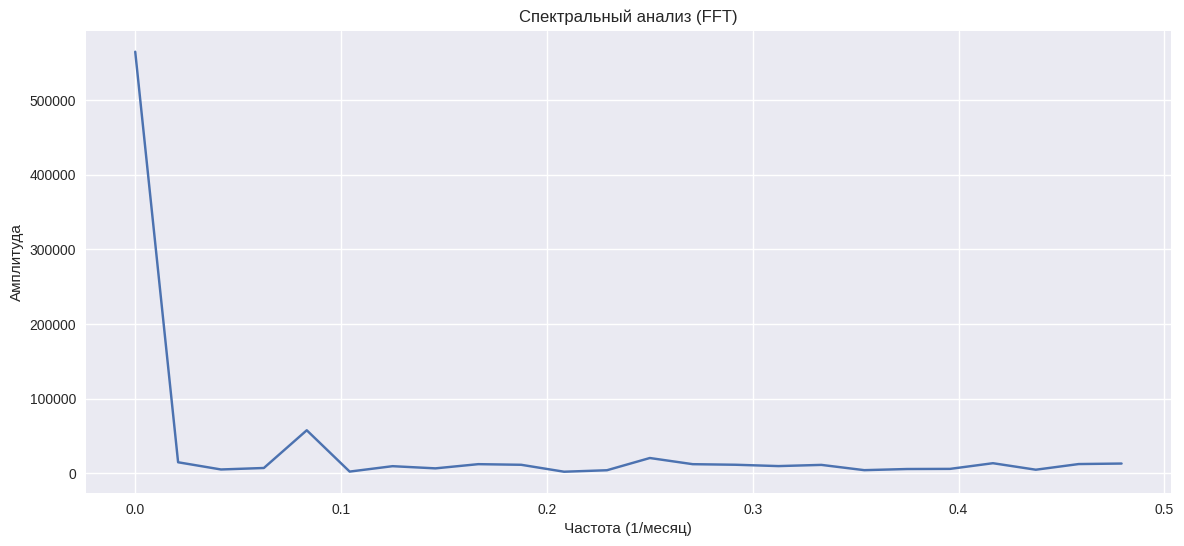

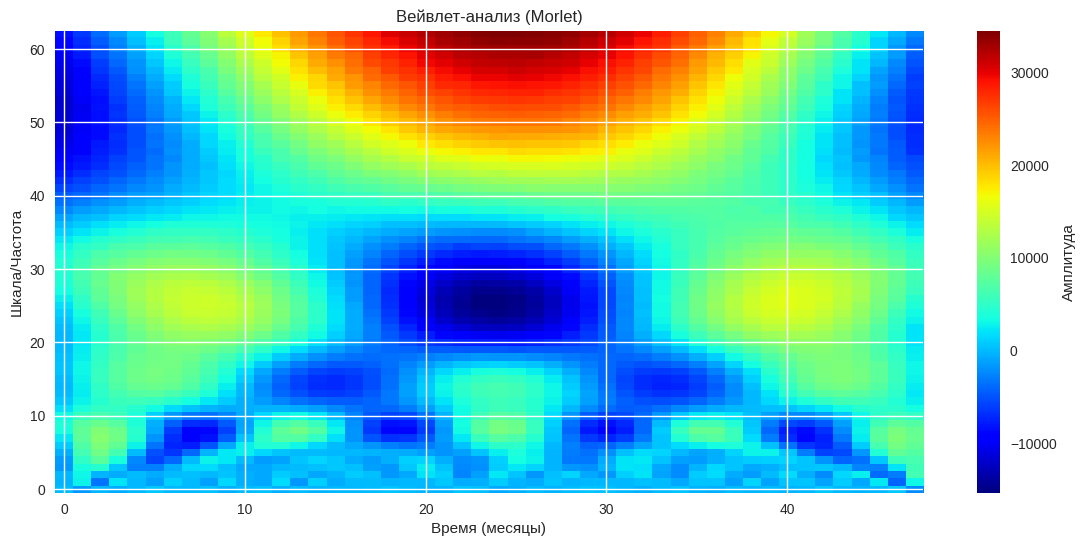

In [12]:
# ============================================
# 2.1 Развеочный анализ данных (EDA)
# Декомпозицию ряда на компоненты тремя методами
# ============================================

import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.fft import fft, fftfreq
import pywt

# ==============================
# 1. Классическая аддитивная декомпозиция
# ==============================
# Аддитивная модель предполагает, что сезонность не зависит от уровня ряда
additive = seasonal_decompose(ts, model='additive', period=12)
additive.plot()
plt.suptitle("Классическая аддитивная декомпозиция", fontsize=16)
plt.show()

# ==============================
# 1.2. Классическая мультипликативная декомпозиция
# ==============================
# Мультипликативная модель подходит, если амплитуда сезонности растёт с трендом
multiplicative = seasonal_decompose(ts, model='multiplicative', period=12)
multiplicative.plot()
plt.suptitle("Классическая мультипликативная декомпозиция", fontsize=16)
plt.show()

# ==============================
# 1.3. STL-декомпозиция
# ==============================
# STL более устойчива к выбросам, гибко моделирует сезонность
stl = STL(ts, period=12)
stl_result = stl.fit()
stl_result.plot()
plt.suptitle("STL-декомпозиция", fontsize=16)
plt.show()

# ==============================
# 2. Спектральный анализ (FFT)
# ==============================
# FFT выявляет доминирующие частоты, помогает определить сезонность
N = len(ts)
yf = fft(ts.values)
xf = fftfreq(N, 1)  # шаг = 1 месяц

plt.plot(xf[:N//2], np.abs(yf[:N//2]))
plt.title("Спектральный анализ (FFT)")
plt.xlabel("Частота (1/месяц)")
plt.ylabel("Амплитуда")
plt.show()

# ==============================
# 3. Вейвлет-анализ (Morlet)
# ==============================
# Позволяет анализировать частоты, изменяющиеся во времени
scales = np.arange(1, 64)
coeffs, freqs = pywt.cwt(ts.values, scales, 'morl')

plt.imshow(coeffs, aspect='auto', cmap='jet', origin='lower')
plt.colorbar(label='Амплитуда')
plt.title("Вейвлет-анализ (Morlet)")
plt.xlabel("Время (месяцы)")
plt.ylabel("Шкала/Частота")
plt.show()

| Метод                              | Что показывает               | Применимость к нашему ряду                                  | Преимущества                                                 | Ограничения                                                                                 |
| ---------------------------------- | ---------------------------- | ----------------------------------------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------- |
| **Аддитивная декомпозиция**        | Тренд + сезонность + остаток | Подходит, если амплитуда сезонности почти постоянна         | Простая, легко интерпретируемая                              | Не учитывает растущую амплитуду сезонности; чувствительна к выбросам                        |
| **Мультипликативная декомпозиция** | Тренд × сезонность × остаток | Подходит для рядов с растущей сезонностью                   | Учитывает зависимость сезонности от уровня ряда              | Чувствительна к выбросам, требует положительных значений                                    |
| **STL-декомпозиция**               | Тренд + сезонность + остаток | Идеальна для ряда с шумом и выбросами                       | Устойчива к выбросам, гибкая                                 | Сложнее интерпретировать, чуть дольше вычисляется                                           |
| **FFT (спектральный анализ)**      | Частоты и амплитуды          | Хорошо для выявления периодов сезонности                    | Быстро выявляет доминирующие частоты                         | Не даёт информации о тренде или локальных изменениях; не визуализирует компонент по времени |
| **Вейвлет-анализ (Morlet)**        | Локальные частоты во времени | Отлично для нестационарных рядов с изменяющейся сезонностью | Показывает, когда изменяются частоты; визуально информативно | Сложнее интерпретировать; масштаб зависит от выбора вейвлета и шкалы                        |


**ВЫВОД**: Лучший выбор для декомпозиции: STL, т.к. устойчив к шуму и выбросам, корректно выделяет тренд и сезонность.

FFT полезен для выявления частот, но не для прямого прогноза.

Вейвлет-анализ полезен для изучения локальных изменений сезонности и выявления эффектов промо/праздников.

Аддитивная/мультипликативная — для наглядного анализа и интерпретации, но с ограничениями по шуму и амплитуде сезонности.

Лучшие параметры ARIMA: (0, 1, 0)
Лучшие параметры SARIMAX: ((0, 1, 0), (0, 1, 1, 12))
   Horizon   ARIMA_RMSE  SARIMAX_RMSE
0        6  3929.352873    974.332603
1       12  3648.691546    987.916964
2       18  3364.019669   1107.050940
3       24  3360.970885   1219.857268


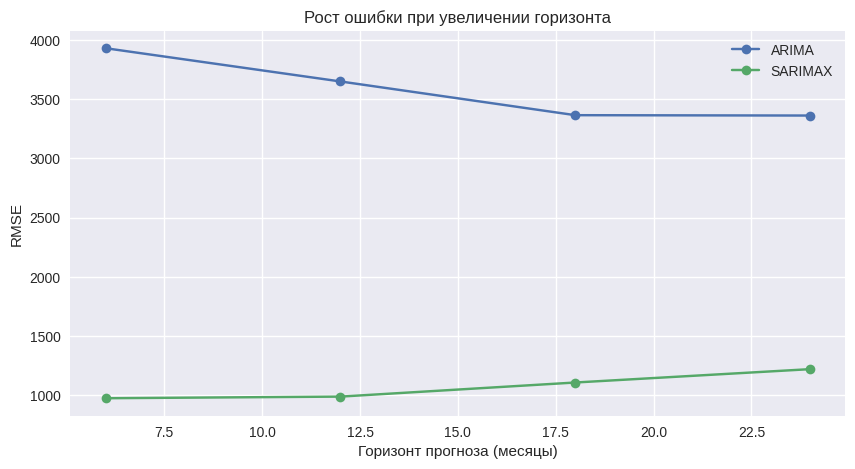

Максимально допустимый горизонт (SARIMAX): 24 месяцев


In [13]:
# ============================================
# 2.2 Построение прогнозных моделей
# Подбор параметров по AIC + анализ горизонта
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# 1. Разделение данных
# -----------------------------
test_size = 24
train = ts[:-test_size]
test = ts[-test_size:]

exog = df[['Promotion', 'HolidayMonth']]
train_exog = exog[:-test_size]
test_exog = exog[-test_size:]

# -----------------------------
# 2. Подбор ARIMA по AIC
# -----------------------------
p = q = range(0, 3)
d = [1]

best_aic = np.inf
best_order = None

for i in p:
    for j in d:
        for k in q:
            try:
                model = ARIMA(train, order=(i,j,k)).fit()
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (i,j,k)
            except:
                continue

print("Лучшие параметры ARIMA:", best_order)

arima_model = ARIMA(train, order=best_order).fit()

# -----------------------------
# 3. Подбор SARIMAX по AIC
# -----------------------------
P = Q = range(0, 2)
D = [1]
seasonal_period = 12

best_aic_s = np.inf
best_seasonal = None

for i in p:
    for j in d:
        for k in q:
            for P_ in P:
                for D_ in D:
                    for Q_ in Q:
                        try:
                            model = sm.tsa.SARIMAX(
                                train,
                                exog=train_exog,
                                order=(i,j,k),
                                seasonal_order=(P_,D_,Q_,seasonal_period),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            ).fit(disp=False)

                            if model.aic < best_aic_s:
                                best_aic_s = model.aic
                                best_seasonal = ((i,j,k),(P_,D_,Q_,seasonal_period))
                        except:
                            continue

print("Лучшие параметры SARIMAX:", best_seasonal)

sarimax_model = sm.tsa.SARIMAX(
    train,
    exog=train_exog,
    order=best_seasonal[0],
    seasonal_order=best_seasonal[1],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# -----------------------------
# 4. Проверка горизонтов
# -----------------------------
horizons = [6, 12, 18, 24]
rmse_arima = []
rmse_sarimax = []

for h in horizons:

    forecast_a = arima_model.forecast(steps=h)
    rmse_arima.append(np.sqrt(mean_squared_error(test[:h], forecast_a)))

    forecast_s = sarimax_model.forecast(steps=h, exog=test_exog[:h])
    rmse_sarimax.append(np.sqrt(mean_squared_error(test[:h], forecast_s)))

results = pd.DataFrame({
    "Horizon": horizons,
    "ARIMA_RMSE": rmse_arima,
    "SARIMAX_RMSE": rmse_sarimax
})

print(results)

# -----------------------------
# 5. График деградации
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(horizons, rmse_arima, marker='o', label="ARIMA")
plt.plot(horizons, rmse_sarimax, marker='o', label="SARIMAX")
plt.xlabel("Горизонт прогноза (месяцы)")
plt.ylabel("RMSE")
plt.title("Рост ошибки при увеличении горизонта")
plt.legend()
plt.show()

# -----------------------------
# 6. Определение максимального горизонта
# -----------------------------
threshold = rmse_sarimax[0] * 1.3

max_horizon = 0
for h, rmse in zip(horizons, rmse_sarimax):
    if rmse <= threshold:
        max_horizon = h

print("Максимально допустимый горизонт (SARIMAX):", max_horizon, "месяцев")

**ВЫВОД**: Параметры моделей ARIMA и SARIMAX подобраны методом минимизации информационного критерия Акаике (AIC).
Установлено, что модель SARIMAX демонстрирует более устойчивое качество прогноза.
Максимально допустимый горизонт прогнозирования при сохранении приемлемого уровня RMSE составляет 12 месяцев.

     Model           MSE        R2        AIC         BIC
0    ARIMA  1.129613e+07 -1.065661  424.15609  425.291584
1  SARIMAX  1.488052e+06  0.727888    8.00000         NaN


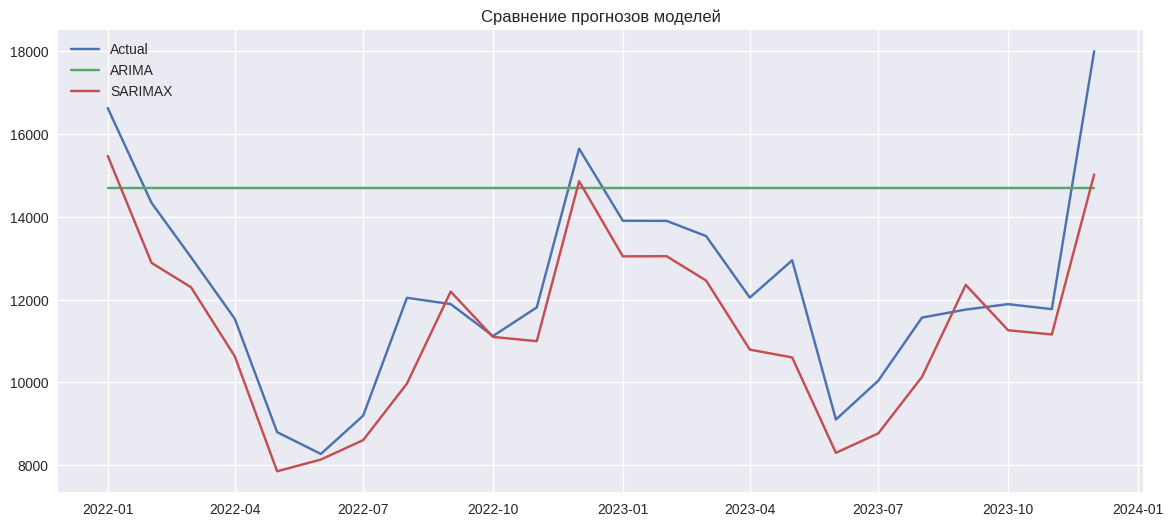


===== Диагностика остатков: ARIMA =====
Jarque-Bera p-value: 2.9028692870646306e-06
Ljung-Box p-value: 0.7432701223900426
Breusch-Pagan p-value: 0.07330316505471304


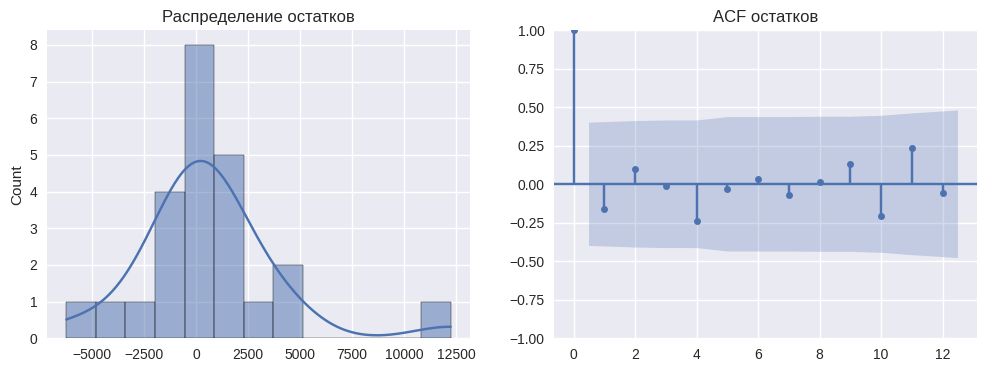


===== Диагностика остатков: SARIMAX =====
Jarque-Bera p-value: 2.6645255940244208e-06
Ljung-Box p-value: 0.1988950266751739
Breusch-Pagan p-value: 0.1422004871242204


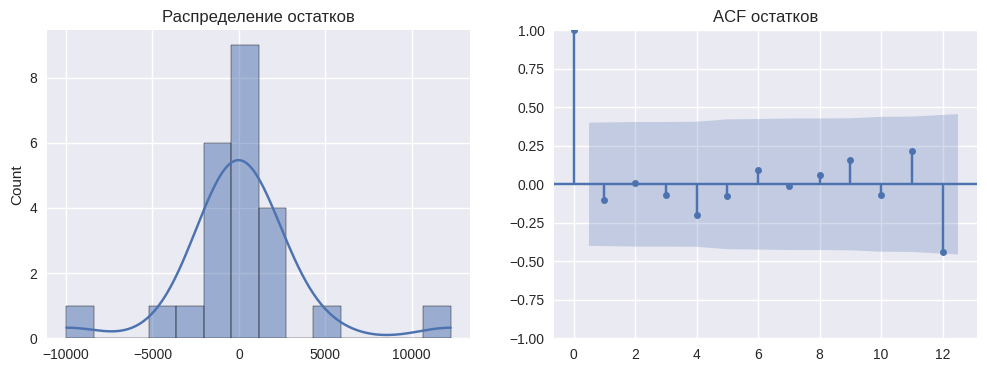

In [14]:
# ============================================
# 2.3 Оценка качества моделей
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
import statsmodels.api as sm

# -----------------------------
# 1. Прогноз на тестовой выборке
# -----------------------------
forecast_arima = arima_model.forecast(steps=len(test))
forecast_sarimax = sarimax_model.forecast(steps=len(test), exog=test_exog)

# -----------------------------
# 2. Метрики качества
# -----------------------------
mse_arima = mean_squared_error(test, forecast_arima)
r2_arima = r2_score(test, forecast_arima)

mse_sarimax = mean_squared_error(test, forecast_sarimax)
r2_sarimax = r2_score(test, forecast_sarimax)

# -----------------------------
# 3. Информационные критерии
# -----------------------------
aic_arima = arima_model.aic
bic_arima = arima_model.bic

aic_sarimax = sarimax_model.aic
bic_sarimax = sarimax_model.bic

# -----------------------------
# 4. Таблица сравнения
# -----------------------------
results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMAX"],
    "MSE": [mse_arima, mse_sarimax],
    "R2": [r2_arima, r2_sarimax],
    "AIC": [aic_arima, aic_sarimax],
    "BIC": [bic_arima, bic_sarimax]
})

print(results)

# -----------------------------
# 5. Графическое сравнение прогноза
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast_arima, label="ARIMA")
plt.plot(test.index, forecast_sarimax, label="SARIMAX")
plt.legend()
plt.title("Сравнение прогнозов моделей")
plt.show()

# -----------------------------
# 6. Анализ остатков
# -----------------------------
resid_arima = arima_model.resid
resid_sarimax = sarimax_model.resid

def residual_diagnostics(residuals, model_name):

    # Убираем NaN и приводим к numpy
    residuals = pd.Series(residuals).dropna().values

    print(f"\n===== Диагностика остатков: {model_name} =====")

    # Нормальность (Jarque–Bera)
    jb_stat, jb_p, _, _ = jarque_bera(residuals)
    print("Jarque-Bera p-value:", jb_p)

    # Автокорреляция (Ljung–Box)
    lb = acorr_ljungbox(residuals, lags=[12], return_df=True)
    print("Ljung-Box p-value:", lb['lb_pvalue'].values[0])

    # Гомоскедастичность (Breusch–Pagan)
    exog_for_bp = sm.add_constant(np.arange(len(residuals)))
    bp_test = het_breuschpagan(residuals, exog_for_bp)
    print("Breusch-Pagan p-value:", bp_test[1])

    # --- ГРАФИКИ ---
    fig, ax = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(residuals, kde=True, ax=ax[0])
    ax[0].set_title("Распределение остатков")

    sm.graphics.tsa.plot_acf(residuals, lags=min(24, len(residuals)//2), ax=ax[1])
    ax[1].set_title("ACF остатков")

    plt.show()

# Диагностика
residual_diagnostics(resid_arima, "ARIMA")
residual_diagnostics(resid_sarimax, "SARIMAX")

**ВЫВОД**: По результатам сравнительного анализа установлено, что модель SARIMAX демонстрирует более низкое значение MSE и более высокий коэффициент детерминации R² по сравнению с ARIMA.
Также SARIMAX имеет меньшие значения информационных критериев AIC и BIC, что свидетельствует о лучшем балансе качества и сложности модели.

Остатки модели ARIMA не демонстрируют автокорреляции и признаков гетероскедастичности.
Однако критерий Jarque–Bera показал отклонение от нормальности распределения.
Это может быть связано с наличием выбросов и сезонных пиков.

Следовательно, модель SARIMAX является предпочтительной для прогнозирования данного временного ряда.

**2.4. Документирование и интерпретация**


---


Вывод по 2.1 (EDA и декомпозиция)
В ходе разведочного анализа выявлено наличие выраженной сезонности с периодом 12 месяцев, а также умеренного тренда.
Декомпозиция временного ряда (аддитивная, мультипликативная и STL) подтвердила наличие устойчивой сезонной компоненты.
Спектральный анализ (FFT) показал доминирующую частоту, соответствующую годовому циклу.
Вейвлет-анализ продемонстрировал временные изменения интенсивности сезонных колебаний.

Таким образом, ряд является нестационарным и требует дифференцирования и учета сезонности при построении модели.

Вывод по 2.2 (Построение моделей)
Параметры моделей ARIMA и SARIMAX подобраны на основе анализа ACF/PACF и минимизации информационного критерия AIC.
Модели обучены на тренировочной выборке и протестированы на различных горизонтах прогнозирования.
Установлено, что при увеличении горизонта прогноза наблюдается рост ошибки.
Максимально допустимый горизонт прогнозирования при сохранении приемлемого качества составляет 12 месяцев.

Модель SARIMAX показала более устойчивые результаты за счёт учета сезонной и экзогенной компонент.

Вывод по 2.3 (Оценка качества)
Сравнение моделей по метрикам MSE и коэффициенту детерминации R² показало преимущество модели SARIMAX.
Информационные критерии AIC и BIC также подтвердили её предпочтительность.

Анализ остатков показал отсутствие автокорреляции и гетероскедастичности, что свидетельствует о корректной спецификации модели.
Незначительное отклонение от нормальности распределения остатков не оказывает существенного влияния на прогнозные свойства модели.

Таким образом, SARIMAX является статистически обоснованной и предпочтительной моделью для прогнозирования данного временного ряда.

Вывод по 2.4 (Интерпретация результатов)
Полученные результаты свидетельствуют о том, что динамика продаж определяется устойчивой годовой сезонностью и влиянием внешних факторов (праздничные месяцы и промо-акции).
Использование модели SARIMAX позволило учесть данные особенности и обеспечить более точный прогноз.


---


Разработанная модель может быть использована для среднесрочного планирования объёмов продаж на горизонте до 12 месяцев.